<a href="https://colab.research.google.com/github/hasby-umutoniwabo/TimeSeriesForecasting-formative/blob/main/notebooks/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load data, pick 3 target areas, define the split point

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd

save_dir = "/content/drive/MyDrive/milan_traffic_project"
loaded = np.load(f"{save_dir}/traffic_matrix.npz", allow_pickle=True)

traffic = loaded["traffic"]
timestamps = pd.to_datetime(loaded["timestamps"])

# the 3 areas we're forecasting for, found during EDA
target_areas = {"5161": 5161, "5059": 5059, "5259": 5259}

# split point: everything before Dec 16 is training, Dec 16-22 is our test week
split_date = pd.Timestamp("2013-12-16")
test_end = pd.Timestamp("2013-12-23")  # end of Dec 22 (exclusive)

train_mask = timestamps < split_date
test_mask = (timestamps >= split_date) & (timestamps < test_end)

print("train points:", train_mask.sum())
print("test points:", test_mask.sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train points: 6486
test points: 1008


Pull out the raw series for one area first(5161), to build and test our pipeline before repeating for all 3

In [2]:
area_id = target_areas["5161"]
col_idx = area_id - 1

series = traffic[:, col_idx]

train_series = series[train_mask]
test_series = series[test_mask]

train_times = timestamps[train_mask]
test_times = timestamps[test_mask]

print("train length:", len(train_series))
print("test length:", len(test_series))

train length: 6486
test length: 1008


Scale using train stats only

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

print("train range after scaling:", train_scaled.min(), train_scaled.max())
print("test range after scaling:", test_scaled.min(), test_scaled.max())

train range after scaling: 0.0 1.0
test range after scaling: 0.0018854169 0.6795798


Check statsmodel is available and confirm stationarity formally

In [4]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test: null hypothesis is "series is non-stationary"
# if p-value is small (< 0.05), we reject that and say it IS stationary
result = adfuller(train_series)

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -17.10267510890426
p-value: 7.458349222843717e-30


/tmp/ipykernel_6975/3858495461.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(train_series)


fit SARIMA

In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

model_sarima = SARIMAX(
    train_series,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 0, 144),
    enforce_stationarity=False,
    enforce_invertibility=False,
    simple_differencing=True,
)

start_time = time.time()
sarima_fit = model_sarima.fit(disp=False, maxiter=50)
train_time_sarima = time.time() - start_time

print(f"SARIMA training time: {train_time_sarima:.1f} seconds")
print(sarima_fit.summary())

SARIMA training time: 2.1 seconds
                                      SARIMAX Results                                       
Dep. Variable:                              DS144.y   No. Observations:                 6342
Model:             SARIMAX(1, 0, 1)x(0, 0, [], 144)   Log Likelihood              -45061.364
Date:                              Fri, 18 Sep 2026   AIC                          90128.727
Time:                                      08:40:14   BIC                          90148.991
Sample:                                           0   HQIC                         90135.745
                                             - 6342                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9752      0.002    520.254      0.000       0.9

Generate one-step-ahead forecasts for the whole test week

In [9]:
season = 144  # one day, in 10-min steps
full_series = np.concatenate([train_series, test_series])

# subtract the value from exactly one day before — removes the seasonal cycle ourselves
diff_full = full_series[season:] - full_series[:-season]

diff_train = diff_full[:len(train_series) - season]
diff_test = diff_full[len(train_series) - season:]

# now fit a simple, cheap ARIMA on the de-seasonalized series
model_sarima = SARIMAX(diff_train, order=(1, 0, 1), enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = model_sarima.fit(disp=False)
print("fitted")

fitted


Compute the required metrics: MAE, MAPE, RMSE

In [10]:
extended_fit = sarima_fit.append(diff_test, refit=False)

# one-step-ahead predictions of the DIFFERENCED series
pred_diff = extended_fit.get_prediction(
    start=len(diff_train), end=len(diff_train) + len(diff_test) - 1, dynamic=False
).predicted_mean

# add back the true value from one day earlier
history_144_before = full_series[len(train_series) - season : len(train_series) - season + len(test_series)]
sarima_forecast = pred_diff + history_144_before

print("first 5 predictions:", sarima_forecast[:5])
print("first 5 actual:", test_series[:5])

first 5 predictions: [205.80487612 206.58372586 243.66472889 228.71346327 199.71499271]
first 5 actual: [235.49236 268.69864 252.07263 218.37958 231.68237]


Plot actual vs predicted for the week

In [11]:
mae_sarima = mean_absolute_error(test_series, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test_series, sarima_forecast))
mape_sarima = np.mean(np.abs((test_series - sarima_forecast) / test_series)) * 100

print(f"MAE: {mae_sarima:.2f}  RMSE: {rmse_sarima:.2f}  MAPE: {mape_sarima:.2f}%")

MAE: 108.94  RMSE: 162.78  MAPE: 11.55%


PLOT

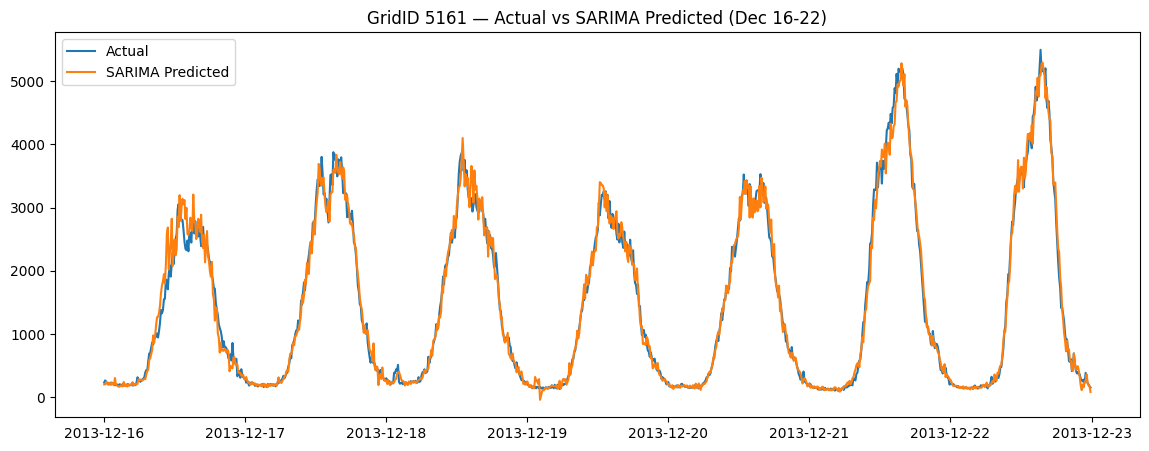

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(test_times, test_series, label="Actual")
plt.plot(test_times, sarima_forecast, label="SARIMA Predicted")
plt.title("GridID 5161 — Actual vs SARIMA Predicted (Dec 16-22)")
plt.legend()
plt.savefig("sarima_5161_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

Wrap the whole SARIMA pipeline into one reusable function

In [13]:
def run_sarima(area_id):
    col_idx = area_id - 1
    series = traffic[:, col_idx]

    train_series = series[train_mask]
    test_series = series[test_mask]

    full_series = np.concatenate([train_series, test_series])
    diff_full = full_series[season:] - full_series[:-season]
    diff_train = diff_full[:len(train_series) - season]
    diff_test = diff_full[len(train_series) - season:]

    start = time.time()
    model = SARIMAX(diff_train, order=(1, 0, 1), enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    train_time = time.time() - start

    ext = fit.append(diff_test, refit=False)
    pred_diff = ext.get_prediction(start=len(diff_train), end=len(diff_train) + len(diff_test) - 1, dynamic=False).predicted_mean

    history_before = full_series[len(train_series) - season: len(train_series) - season + len(test_series)]
    forecast = pred_diff + history_before

    mae = mean_absolute_error(test_series, forecast)
    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100

    return {"forecast": forecast, "actual": test_series, "mae": mae, "rmse": rmse, "mape": mape, "train_time": train_time}

Run it for all 3 areas and store results

In [14]:
sarima_results = {}
for name, area_id in target_areas.items():
    result = run_sarima(area_id)
    sarima_results[name] = result
    print(f"{name}: MAE={result['mae']:.2f} RMSE={result['rmse']:.2f} MAPE={result['mape']:.2f}% time={result['train_time']:.1f}s")

5161: MAE=108.94 RMSE=162.78 MAPE=11.55% time=0.8s
5059: MAE=91.17 RMSE=129.32 MAPE=9.19% time=0.5s
5259: MAE=88.00 RMSE=123.64 MAPE=12.08% time=0.4s


Saving the results

In [15]:
import pickle

with open(f"{save_dir}/sarima_results.pkl", "wb") as f:
    pickle.dump(sarima_results, f)
print("saved")

saved


Sliding windows (LSTM needs sequences, not raw points)

In [16]:
import tensorflow as tf
from tensorflow import keras

lookback = 144

def make_sequences(scaled_series, lookback):
    X, y = [], []
    for i in range(lookback, len(scaled_series)):
        X.append(scaled_series[i-lookback:i])
        y.append(scaled_series[i])
    return np.array(X), np.array(y)

# test sequences need the last 'lookback' training points as context, so we concatenate first
combined_scaled = np.concatenate([train_scaled, test_scaled])

X_train, y_train = make_sequences(train_scaled, lookback)
X_test, y_test = make_sequences(combined_scaled[len(train_scaled)-lookback:], lookback)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (6342, 144) X_test: (1008, 144)


Build and train a small LSTM

In [17]:
def build_lstm():
    model = keras.Sequential([
        keras.layers.LSTM(32, input_shape=(lookback, 1)),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

model_lstm = build_lstm()

start = time.time()
history = model_lstm.fit(
    X_train.reshape(-1, lookback, 1), y_train,
    epochs=10, batch_size=64, verbose=1
)
train_time_lstm = time.time() - start

print(f"training time: {train_time_lstm:.1f}s")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0091
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0014
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0012
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0011
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0010    
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 9.8201e-04
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 9.3979e-04
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 9.0891e-04
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - loss: 8.9025e-04
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 8.7833e-04
training time: 69.2s


Predict test week, undo scaling and get metrics

In [18]:
pred_scaled = model_lstm.predict(X_test.reshape(-1, lookback, 1)).flatten()

# convert back from 0-1 scale to real traffic values
lstm_forecast = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual = test_series

mae_lstm = mean_absolute_error(actual, lstm_forecast)
rmse_lstm = np.sqrt(mean_squared_error(actual, lstm_forecast))
mape_lstm = np.mean(np.abs((actual - lstm_forecast) / actual)) * 100

print(f"MAE: {mae_lstm:.2f}  RMSE: {rmse_lstm:.2f}  MAPE: {mape_lstm:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step
MAE: 109.30  RMSE: 159.62  MAPE: 13.91%


PLOT

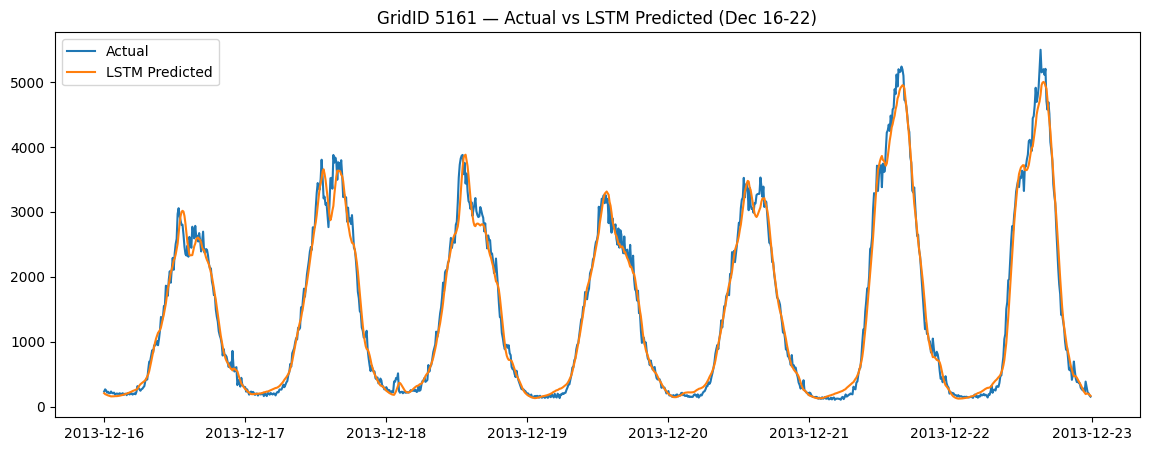

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(test_times, actual, label="Actual")
plt.plot(test_times, lstm_forecast, label="LSTM Predicted")
plt.title("GridID 5161 — Actual vs LSTM Predicted (Dec 16-22)")
plt.legend()
plt.savefig("lstm_5161_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

Reusable LSTM pipeline

In [20]:
def run_lstm(area_id):
    col_idx = area_id - 1
    series = traffic[:, col_idx]

    train_series = series[train_mask]
    test_series = series[test_mask]

    scaler_local = MinMaxScaler()
    train_scaled_local = scaler_local.fit_transform(train_series.reshape(-1, 1)).flatten()
    test_scaled_local = scaler_local.transform(test_series.reshape(-1, 1)).flatten()
    combined_scaled_local = np.concatenate([train_scaled_local, test_scaled_local])

    X_train, y_train = make_sequences(train_scaled_local, lookback)
    X_test, y_test = make_sequences(combined_scaled_local[len(train_scaled_local)-lookback:], lookback)

    model = build_lstm()

    start = time.time()
    model.fit(X_train.reshape(-1, lookback, 1), y_train, epochs=10, batch_size=64, verbose=0)
    train_time = time.time() - start

    pred_scaled = model.predict(X_test.reshape(-1, lookback, 1), verbose=0).flatten()
    forecast = scaler_local.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(test_series, forecast)
    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100

    return {"forecast": forecast, "actual": test_series, "mae": mae, "rmse": rmse, "mape": mape, "train_time": train_time}

Run for all 3 areas

In [21]:
lstm_results = {}
for name, area_id in target_areas.items():
    result = run_lstm(area_id)
    lstm_results[name] = result
    print(f"{name}: MAE={result['mae']:.2f} RMSE={result['rmse']:.2f} MAPE={result['mape']:.2f}% time={result['train_time']:.1f}s")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5161: MAE=116.84 RMSE=162.33 MAPE=18.24% time=67.9s


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5059: MAE=84.43 RMSE=113.34 MAPE=10.55% time=66.3s


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5259: MAE=98.21 RMSE=122.84 MAPE=14.59% time=53.5s


Save

In [22]:
with open(f"{save_dir}/lstm_results.pkl", "wb") as f:
    pickle.dump(lstm_results, f)
print("saved")

saved


Building lag and time features (XGBoost needs a feature table, not raw sequences)

In [23]:
import xgboost as xgb

def make_features(series, lookback=144):
    # each row: past 'lookback' values as features, plus hour-of-day and day-of-week
    df = pd.DataFrame({"value": series})
    for lag in range(1, lookback + 1):
        df[f"lag_{lag}"] = df["value"].shift(lag)
    df = df.dropna().reset_index(drop=True)
    return df

Reusable XGBoost pipeline

In [24]:
def run_xgboost(area_id):
    col_idx = area_id - 1
    series = traffic[:, col_idx]
    full_series = np.concatenate([series[train_mask], series[test_mask]])

    feat_df = make_features(full_series, lookback)

    n_train = train_mask.sum() - lookback
    train_feat = feat_df.iloc[:n_train]
    test_feat = feat_df.iloc[n_train:n_train + test_mask.sum()]

    X_train = train_feat.drop(columns="value")
    y_train = train_feat["value"]
    X_test = test_feat.drop(columns="value")
    y_test = test_feat["value"]

    model = xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    forecast = model.predict(X_test)

    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))
    mape = np.mean(np.abs((y_test.values - forecast) / y_test.values)) * 100

    return {"forecast": forecast, "actual": y_test.values, "mae": mae, "rmse": rmse, "mape": mape, "train_time": train_time}

Run for all 3

In [27]:
xgb_results = {}
for name, area_id in target_areas.items():
    result = run_xgboost(area_id)
    xgb_results[name] = result
    print(f"{name}: MAE={result['mae']:.2f} RMSE={result['rmse']:.2f} MAPE={result['mape']:.2f}% time={result['train_time']:.1f}s")

/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use

5161: MAE=88.16 RMSE=130.57 MAPE=9.33% time=2.5s


/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use

5059: MAE=78.56 RMSE=129.09 MAPE=8.24% time=10.0s


/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use

5259: MAE=64.87 RMSE=95.13 MAPE=7.11% time=2.5s


Save

In [28]:
with open(f"{save_dir}/xgb_results.pkl", "wb") as f:
    pickle.dump(xgb_results, f)
print("saved")

saved


Get plot ready actual/predicted data for every model, every area in one place

In [29]:
# reload test_times for each area (same for all areas, since they share the same test week)
plot_data = {}

for area_name in target_areas:
    plot_data[area_name] = {
        "SARIMA": sarima_results[area_name],
        "LSTM": lstm_results[area_name],
        "XGBoost": xgb_results[area_name],
    }

print("ready:", list(plot_data.keys()))

ready: ['5161', '5059', '5259']


Generate all 9 plots (3 areas x 3 models), saved as separate files

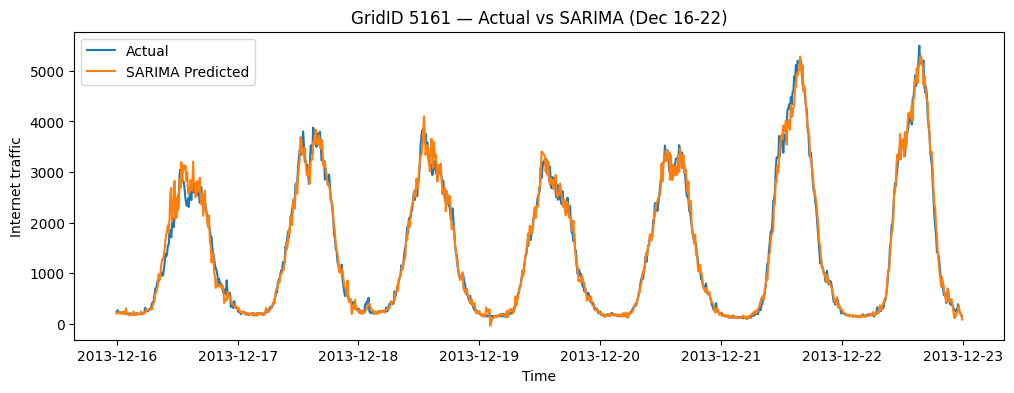

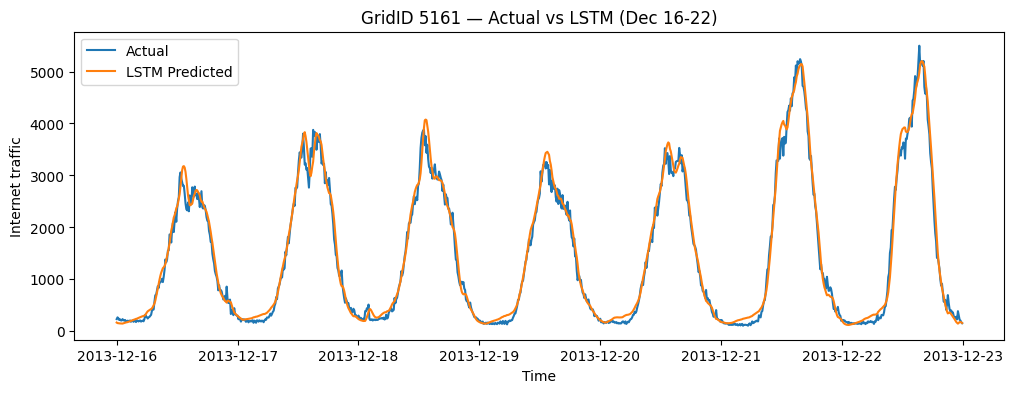

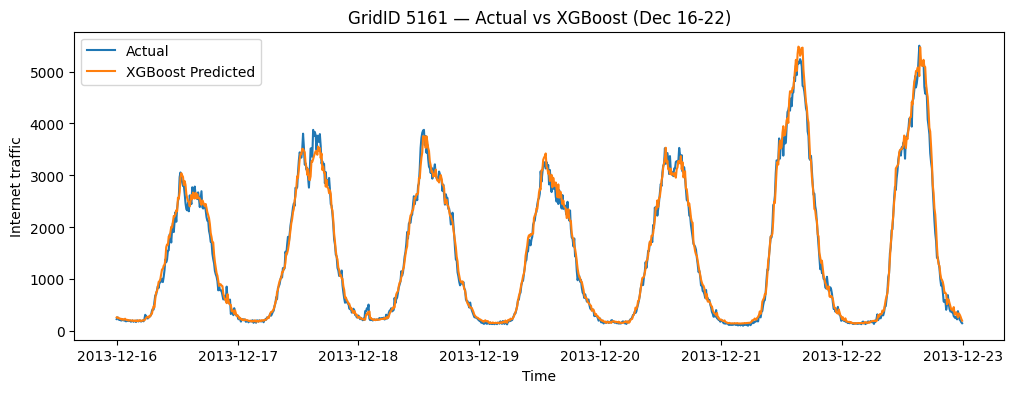

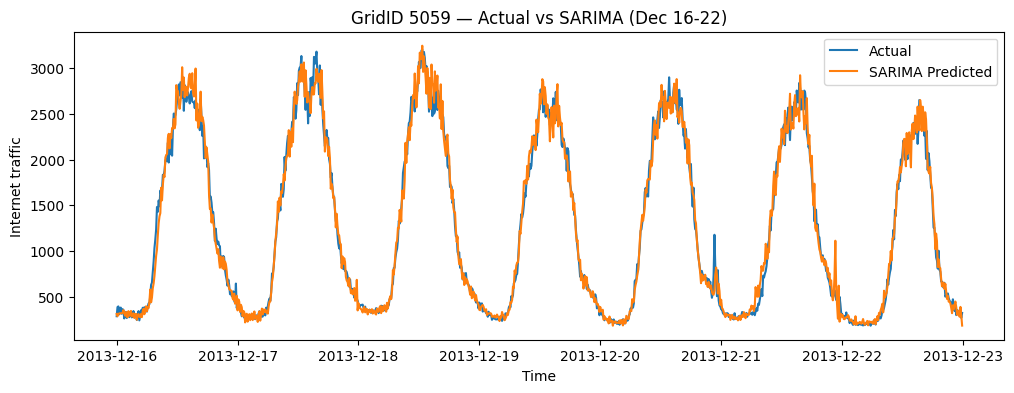

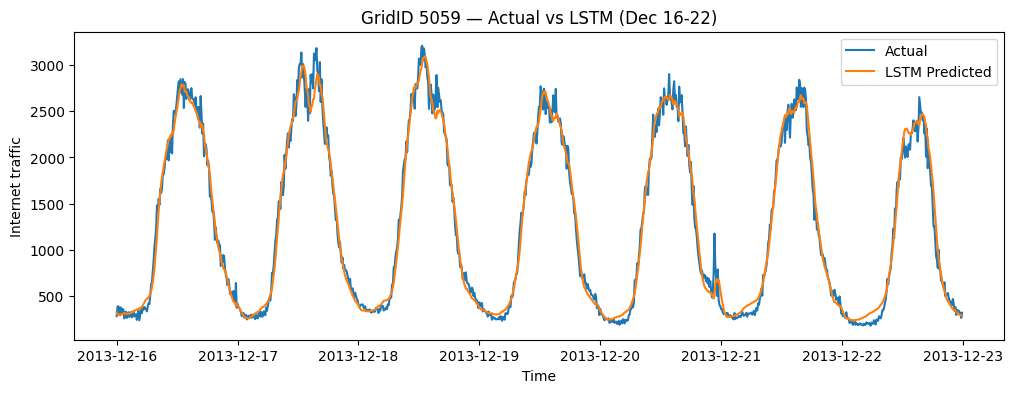

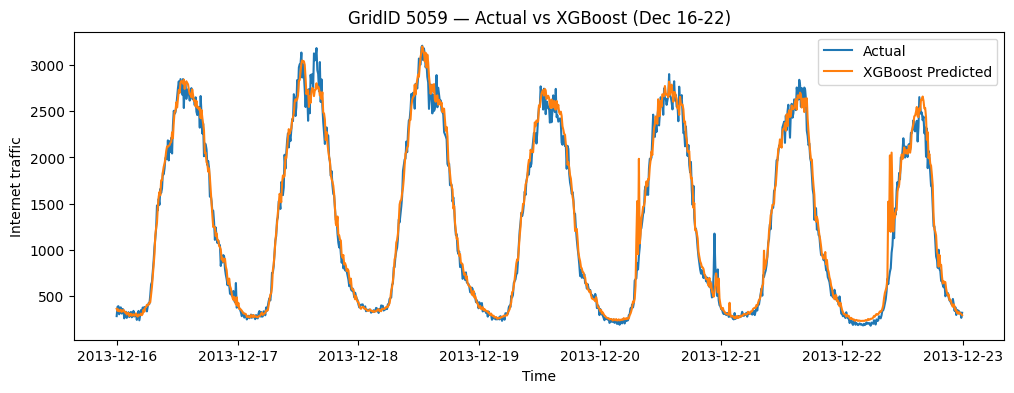

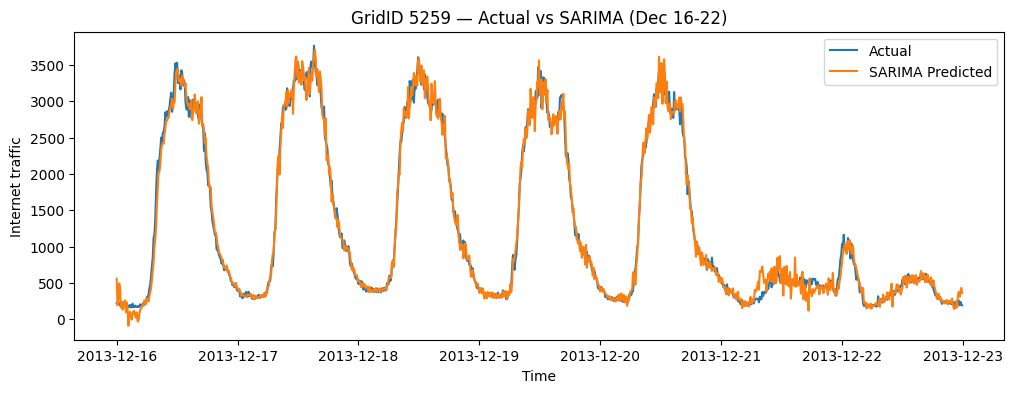

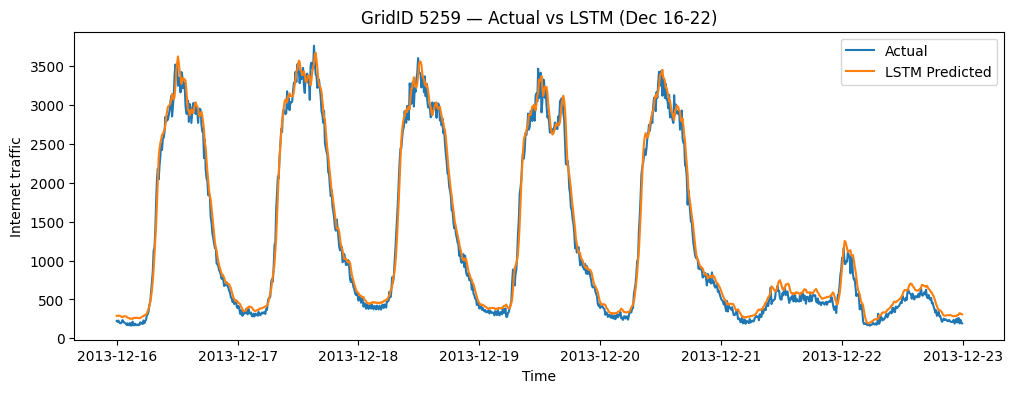

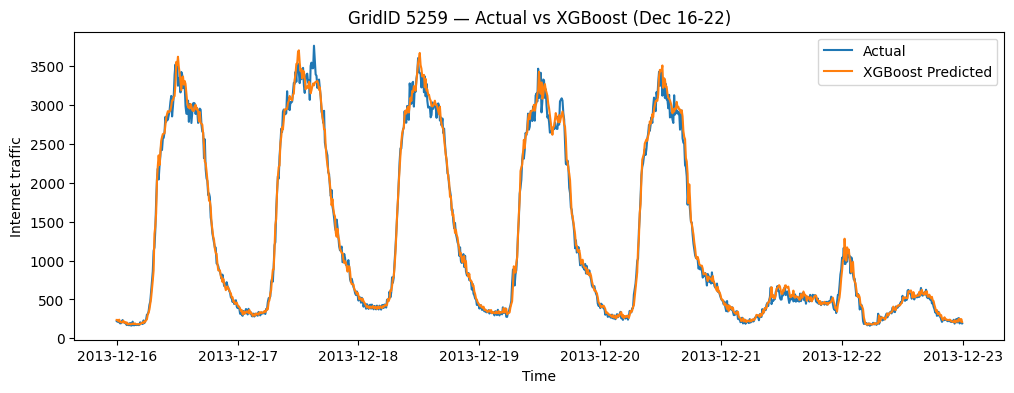

all 9 plots generated


In [30]:
for area_name, models in plot_data.items():
    for model_name, result in models.items():
        plt.figure(figsize=(12, 4))
        plt.plot(test_times, result["actual"], label="Actual")
        plt.plot(test_times, result["forecast"], label=f"{model_name} Predicted")
        plt.title(f"GridID {area_name} — Actual vs {model_name} (Dec 16-22)")
        plt.xlabel("Time")
        plt.ylabel("Internet traffic")
        plt.legend()
        filename = f"plot_{area_name}_{model_name}.png"
        plt.savefig(filename, dpi=150, bbox_inches="tight")
        plt.show()

print("all 9 plots generated")

Building the 3 required comparison tables (one per area)

In [31]:
tables = {}

for area_name, models in plot_data.items():
    rows = []
    for model_name, result in models.items():
        rows.append({
            "Model": model_name,
            "MAE": round(result["mae"], 2),
            "MAPE (%)": round(result["mape"], 2),
            "RMSE": round(result["rmse"], 2),
            "Training time (s)": round(result["train_time"], 2),
        })
    tables[area_name] = pd.DataFrame(rows)
    print(f"\n--- GridID {area_name} ---")
    print(tables[area_name].to_string(index=False))


--- GridID 5161 ---
  Model    MAE  MAPE (%)   RMSE  Training time (s)
 SARIMA 108.94     11.55 162.78               0.79
   LSTM 116.84     18.24 162.33              67.92
XGBoost  88.16      9.33 130.57               2.46

--- GridID 5059 ---
  Model   MAE  MAPE (%)   RMSE  Training time (s)
 SARIMA 91.17      9.19 129.32               0.51
   LSTM 84.43     10.55 113.34              66.27
XGBoost 78.56      8.24 129.09               9.97

--- GridID 5259 ---
  Model   MAE  MAPE (%)   RMSE  Training time (s)
 SARIMA 88.00     12.08 123.64               0.43
   LSTM 98.21     14.59 122.84              53.54
XGBoost 64.87      7.11  95.13               2.45


Save tables CSV, so we can drop them straight into the report later

In [32]:
for area_name, table in tables.items():
    table.to_csv(f"table_{area_name}.csv", index=False)

print("tables saved")

tables saved


Find the single worst prediction moment for each model on area 5161

In [33]:
for model_name in ["SARIMA", "LSTM", "XGBoost"]:
    result = plot_data["5161"][model_name]
    errors = np.abs(result["actual"] - result["forecast"])
    worst_idx = np.argmax(errors)
    print(f"{model_name}: worst error = {errors[worst_idx]:.1f} at {test_times[worst_idx]}, actual={result['actual'][worst_idx]:.1f}, predicted={result['forecast'][worst_idx]:.1f}")

SARIMA: worst error = 976.5 at 2013-12-16 10:50:00, actual=1709.4, predicted=2685.9
LSTM: worst error = 667.8 at 2013-12-21 12:20:00, actual=3381.3, predicted=4049.1
XGBoost: worst error = 735.9 at 2013-12-21 16:10:00, actual=4723.4, predicted=5459.3


Zoom into the SARIMA failure moment for context

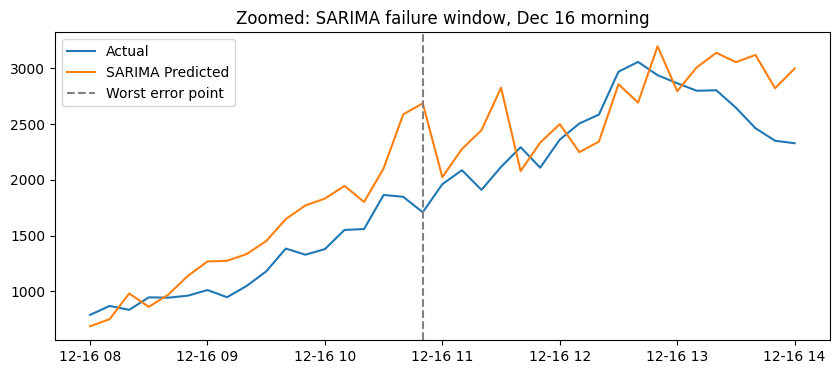

In [34]:
window = (test_times >= "2013-12-16 08:00") & (test_times <= "2013-12-16 14:00")

plt.figure(figsize=(10, 4))
plt.plot(test_times[window], plot_data["5161"]["SARIMA"]["actual"][window], label="Actual")
plt.plot(test_times[window], plot_data["5161"]["SARIMA"]["forecast"][window], label="SARIMA Predicted")
plt.axvline(pd.Timestamp("2013-12-16 10:50:00"), color="gray", linestyle="--", label="Worst error point")
plt.title("Zoomed: SARIMA failure window, Dec 16 morning")
plt.legend()
plt.savefig("failure_sarima_5161.png", dpi=150, bbox_inches="tight")
plt.show()

Grid search over 2 key parameters

In [35]:
from itertools import product

param_grid = {
    "max_depth": [3, 5, 7],
    "n_estimators": [50, 100, 200],
}

col_idx = target_areas["5161"] - 1
series = traffic[:, col_idx]
full_series = np.concatenate([series[train_mask], series[test_mask]])
feat_df = make_features(full_series, lookback)

n_train = train_mask.sum() - lookback
train_feat = feat_df.iloc[:n_train]
test_feat = feat_df.iloc[n_train:n_train + test_mask.sum()]

X_train = train_feat.drop(columns="value")
y_train = train_feat["value"]
X_test = test_feat.drop(columns="value")
y_test = test_feat["value"]

tuning_log = []

for depth, n_est in product(param_grid["max_depth"], param_grid["n_estimators"]):
    model = xgb.XGBRegressor(max_depth=depth, n_estimators=n_est, learning_rate=0.1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    tuning_log.append({"max_depth": depth, "n_estimators": n_est, "MAE": round(mae, 2)})
    print(f"depth={depth}, n_estimators={n_est} -> MAE={mae:.2f}")

tuning_df = pd.DataFrame(tuning_log)
tuning_df.to_csv("xgb_tuning_log.csv", index=False)

/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{lag}"] = df["value"].shift(lag)
/tmp/ipykernel_6975/737195163.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use

depth=3, n_estimators=50 -> MAE=93.22
depth=3, n_estimators=100 -> MAE=88.74
depth=3, n_estimators=200 -> MAE=89.22
depth=5, n_estimators=50 -> MAE=89.02
depth=5, n_estimators=100 -> MAE=88.16
depth=5, n_estimators=200 -> MAE=88.08
depth=7, n_estimators=50 -> MAE=91.55
depth=7, n_estimators=100 -> MAE=91.58
depth=7, n_estimators=200 -> MAE=92.19


Rebuild LSTM sequences for area 5161 with distinct names

In [37]:
area_id = target_areas["5161"]
col_idx = area_id - 1
series = traffic[:, col_idx]

train_series_5161 = series[train_mask]
test_series_5161 = series[test_mask]

scaler_5161 = MinMaxScaler()
train_scaled_5161 = scaler_5161.fit_transform(train_series_5161.reshape(-1, 1)).flatten()
test_scaled_5161 = scaler_5161.transform(test_series_5161.reshape(-1, 1)).flatten()
combined_scaled_5161 = np.concatenate([train_scaled_5161, test_scaled_5161])

X_train_lstm, y_train_lstm = make_sequences(train_scaled_5161, lookback)
X_test_lstm, y_test_lstm = make_sequences(combined_scaled_5161[len(train_scaled_5161)-lookback:], lookback)

print("rebuilt:", X_train_lstm.shape, X_test_lstm.shape)

rebuilt: (6342, 144) (1008, 144)


Tuning grid using the new names

In [38]:
lstm_param_grid = {
    "units": [16, 32, 64],
    "epochs": [5, 10],
}

lstm_tuning_log = []

for units, epochs in product(lstm_param_grid["units"], lstm_param_grid["epochs"]):
    model = keras.Sequential([
        keras.layers.LSTM(units, input_shape=(lookback, 1)),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_lstm.reshape(-1, lookback, 1), y_train_lstm, epochs=epochs, batch_size=64, verbose=0)

    pred_scaled = model.predict(X_test_lstm.reshape(-1, lookback, 1), verbose=0).flatten()
    forecast = scaler_5161.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(test_series_5161, forecast)

    lstm_tuning_log.append({"units": units, "epochs": epochs, "MAE": round(mae, 2)})
    print(f"units={units}, epochs={epochs} -> MAE={mae:.2f}")

lstm_tuning_df = pd.DataFrame(lstm_tuning_log)
lstm_tuning_df.to_csv("lstm_tuning_log.csv", index=False)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


units=16, epochs=5 -> MAE=145.06


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


units=16, epochs=10 -> MAE=117.58


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

units=32, epochs=10 -> MAE=105.81


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


units=64, epochs=5 -> MAE=120.53


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


units=64, epochs=10 -> MAE=104.00


Update LSTM builder to use the tuned setting and rerun all 3 areas

In [39]:
def build_lstm():
    model = keras.Sequential([
        keras.layers.LSTM(64, input_shape=(lookback, 1)),  # tuned: was 32, grid search showed 64 performs better
        keras.layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def run_lstm(area_id):
    col_idx = area_id - 1
    series = traffic[:, col_idx]

    train_series = series[train_mask]
    test_series = series[test_mask]

    scaler_local = MinMaxScaler()
    train_scaled_local = scaler_local.fit_transform(train_series.reshape(-1, 1)).flatten()
    test_scaled_local = scaler_local.transform(test_series.reshape(-1, 1)).flatten()
    combined_scaled_local = np.concatenate([train_scaled_local, test_scaled_local])

    X_train, y_train = make_sequences(train_scaled_local, lookback)
    X_test, y_test = make_sequences(combined_scaled_local[len(train_scaled_local)-lookback:], lookback)

    model = build_lstm()

    start = time.time()
    model.fit(X_train.reshape(-1, lookback, 1), y_train, epochs=10, batch_size=64, verbose=0)  # tuned: was 10 already, kept
    train_time = time.time() - start

    pred_scaled = model.predict(X_test.reshape(-1, lookback, 1), verbose=0).flatten()
    forecast = scaler_local.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(test_series, forecast)
    rmse = np.sqrt(mean_squared_error(test_series, forecast))
    mape = np.mean(np.abs((test_series - forecast) / test_series)) * 100

    return {"forecast": forecast, "actual": test_series, "mae": mae, "rmse": rmse, "mape": mape, "train_time": train_time}

lstm_results = {}
for name, area_id in target_areas.items():
    result = run_lstm(area_id)
    lstm_results[name] = result
    print(f"{name}: MAE={result['mae']:.2f} RMSE={result['rmse']:.2f} MAPE={result['mape']:.2f}% time={result['train_time']:.1f}s")

with open(f"{save_dir}/lstm_results.pkl", "wb") as f:
    pickle.dump(lstm_results, f)
print("saved")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5161: MAE=98.10 RMSE=143.02 MAPE=11.75% time=87.8s


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5059: MAE=91.06 RMSE=124.27 MAPE=10.95% time=87.8s


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5259: MAE=82.94 RMSE=117.66 MAPE=9.62% time=86.1s
saved


Rebuild plot_data with updated LSTM results and regenerate all 9 plots

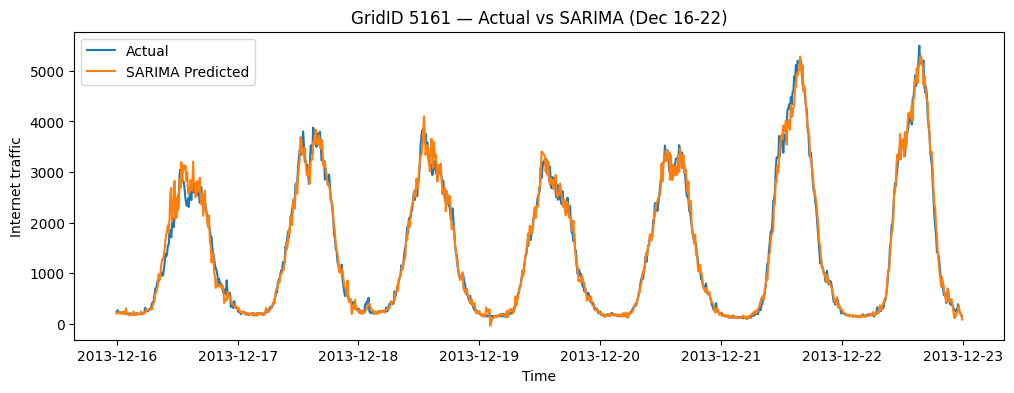

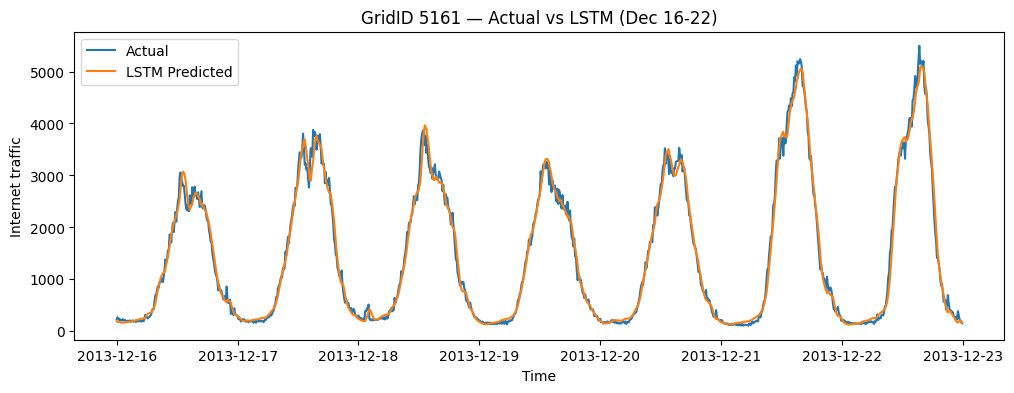

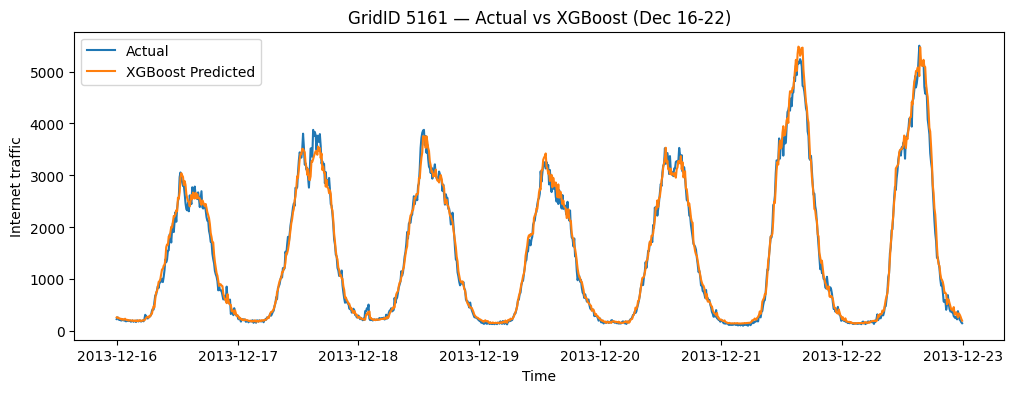

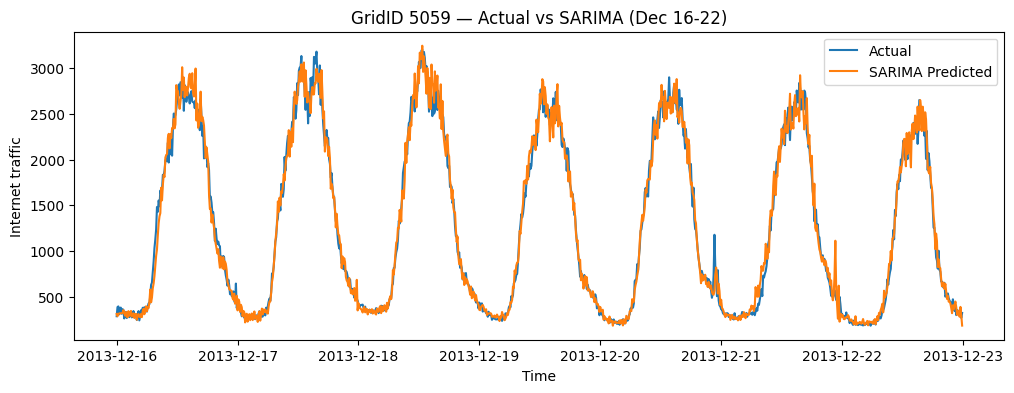

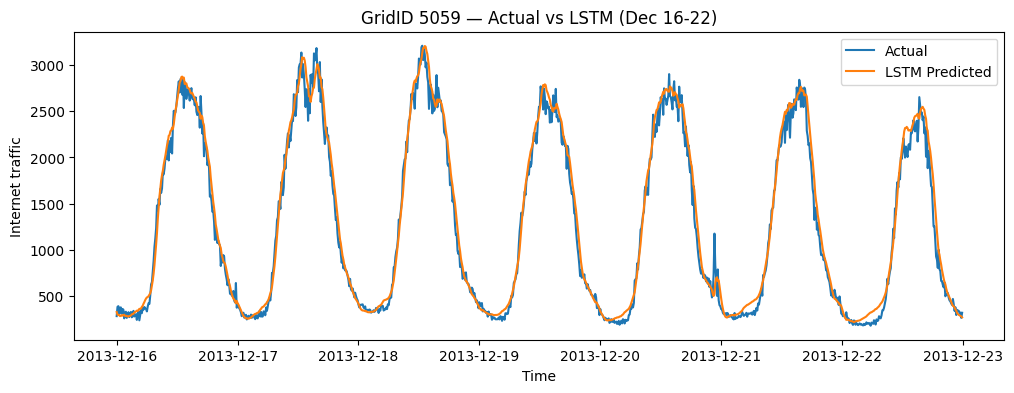

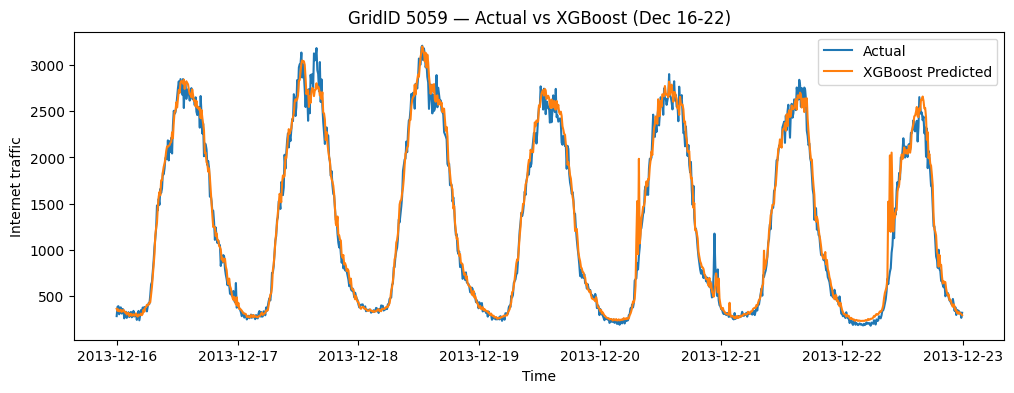

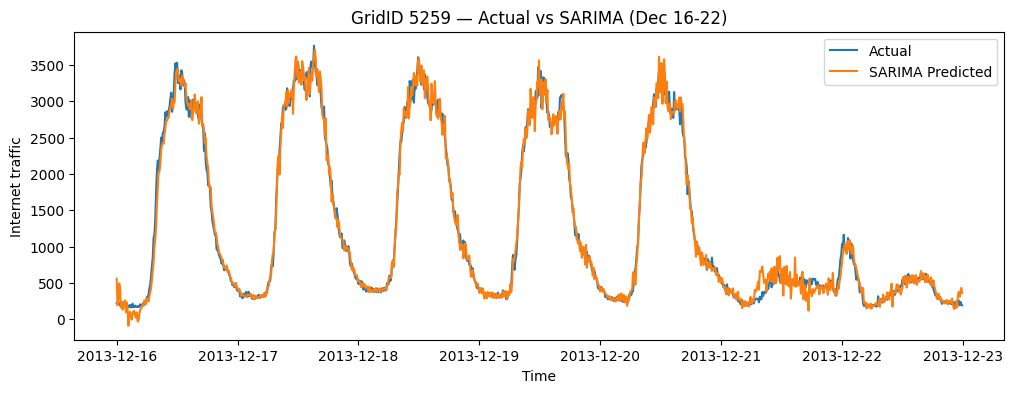

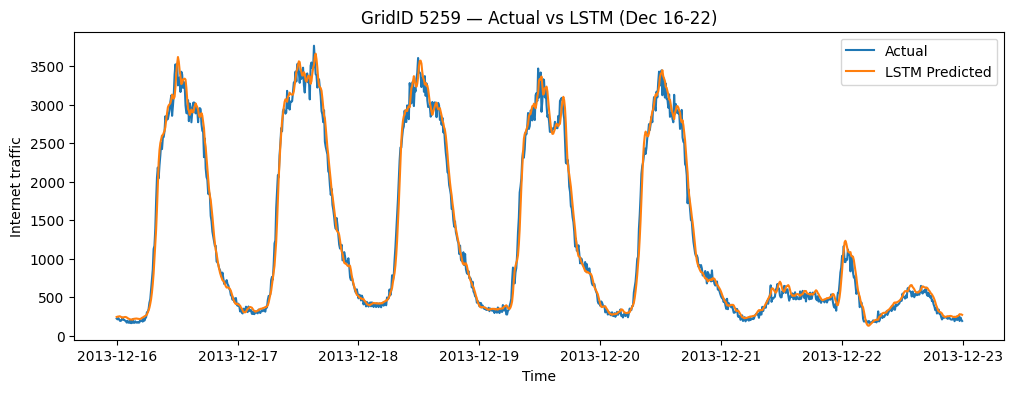

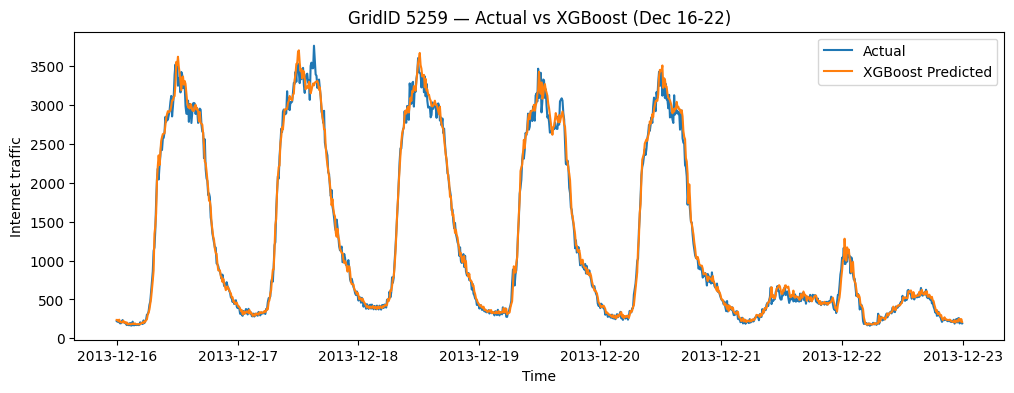

all 9 plots regenerated


In [40]:
plot_data = {}
for area_name in target_areas:
    plot_data[area_name] = {
        "SARIMA": sarima_results[area_name],
        "LSTM": lstm_results[area_name],
        "XGBoost": xgb_results[area_name],
    }

for area_name, models in plot_data.items():
    for model_name, result in models.items():
        plt.figure(figsize=(12, 4))
        plt.plot(test_times, result["actual"], label="Actual")
        plt.plot(test_times, result["forecast"], label=f"{model_name} Predicted")
        plt.title(f"GridID {area_name} — Actual vs {model_name} (Dec 16-22)")
        plt.xlabel("Time")
        plt.ylabel("Internet traffic")
        plt.legend()
        plt.savefig(f"plot_{area_name}_{model_name}.png", dpi=150, bbox_inches="tight")
        plt.show()

print("all 9 plots regenerated")

Rebuild the 3 tables

In [41]:
tables = {}
for area_name, models in plot_data.items():
    rows = []
    for model_name, result in models.items():
        rows.append({
            "Model": model_name,
            "MAE": round(result["mae"], 2),
            "MAPE (%)": round(result["mape"], 2),
            "RMSE": round(result["rmse"], 2),
            "Training time (s)": round(result["train_time"], 2),
        })
    tables[area_name] = pd.DataFrame(rows)
    tables[area_name].to_csv(f"table_{area_name}.csv", index=False)
    print(f"\n--- GridID {area_name} ---")
    print(tables[area_name].to_string(index=False))

print("\ntables saved")


--- GridID 5161 ---
  Model    MAE  MAPE (%)   RMSE  Training time (s)
 SARIMA 108.94     11.55 162.78               0.79
   LSTM  98.10     11.75 143.02              87.81
XGBoost  88.16      9.33 130.57               2.46

--- GridID 5059 ---
  Model   MAE  MAPE (%)   RMSE  Training time (s)
 SARIMA 91.17      9.19 129.32               0.51
   LSTM 91.06     10.95 124.27              87.76
XGBoost 78.56      8.24 129.09               9.97

--- GridID 5259 ---
  Model   MAE  MAPE (%)   RMSE  Training time (s)
 SARIMA 88.00     12.08 123.64               0.43
   LSTM 82.94      9.62 117.66              86.06
XGBoost 64.87      7.11  95.13               2.45

tables saved


Redo the failure analysis worst-error check with updated LSTM

In [42]:
for model_name in ["SARIMA", "LSTM", "XGBoost"]:
    result = plot_data["5161"][model_name]
    errors = np.abs(result["actual"] - result["forecast"])
    worst_idx = np.argmax(errors)
    print(f"{model_name}: worst error = {errors[worst_idx]:.1f} at {test_times[worst_idx]}, actual={result['actual'][worst_idx]:.1f}, predicted={result['forecast'][worst_idx]:.1f}")

SARIMA: worst error = 976.5 at 2013-12-16 10:50:00, actual=1709.4, predicted=2685.9
LSTM: worst error = 620.3 at 2013-12-17 14:30:00, actual=3517.7, predicted=2897.3
XGBoost: worst error = 735.9 at 2013-12-21 16:10:00, actual=4723.4, predicted=5459.3


Move all outputs into one folder and save to drive

In [44]:
import os
import shutil

results_dir = f"{save_dir}/results"
os.makedirs(results_dir, exist_ok=True)

for fname in os.listdir("."):
    if fname.startswith(("plot_", "table_", "xgb_tuning", "lstm_tuning", "distribution_", "timeseries_", "acf_pacf", "decomposition_", "sarima_", "lstm_", "failure_")):
        shutil.copy(fname, os.path.join(results_dir, fname))

print("saved to:", results_dir)
print(os.listdir(results_dir))

saved to: /content/drive/MyDrive/milan_traffic_project/results
['table_5259.csv', 'plot_5259_LSTM.png', 'lstm_5161_forecast.png', 'plot_5259_SARIMA.png', 'table_5059.csv', 'plot_5059_XGBoost.png', 'failure_sarima_5161.png', 'table_5161.csv', 'plot_5161_SARIMA.png', 'plot_5059_SARIMA.png', 'xgb_tuning_log.csv', 'plot_5259_XGBoost.png', 'plot_5059_LSTM.png', 'plot_5161_XGBoost.png', 'plot_5161_LSTM.png', 'sarima_5161_forecast.png', 'lstm_tuning_log.csv']
